## Paso 3. Modelo de árbol de decisión

In [25]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer



In [26]:
df = pd.read_csv("../data/raw/diabetes.csv")

In [27]:
X_train = pd.read_csv("../data/processed/diabetes/X_train.csv")
y_train = pd.read_csv("../data/processed/diabetes/y_train.csv")
X_test = pd.read_csv("../data/processed/diabetes/X_test.csv")
y_test = pd.read_csv("../data/processed/diabetes/y_test.csv")

In [28]:
#Separación de feature y target
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [29]:
#Árbol clásico con criterio de gini
tree_gini = DecisionTreeClassifier(criterion="gini", random_state=42)
tree_gini.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [30]:
#Predicciones y evaluación
y_pred_gini = tree_gini.predict(X_test)
print("Reporte de clasificación (Gini):")
print(classification_report(y_test, y_pred_gini))

Reporte de clasificación (Gini):
              precision    recall  f1-score   support

           0       0.76      0.85      0.80       100
           1       0.64      0.50      0.56        54

    accuracy                           0.73       154
   macro avg       0.70      0.68      0.68       154
weighted avg       0.72      0.73      0.72       154



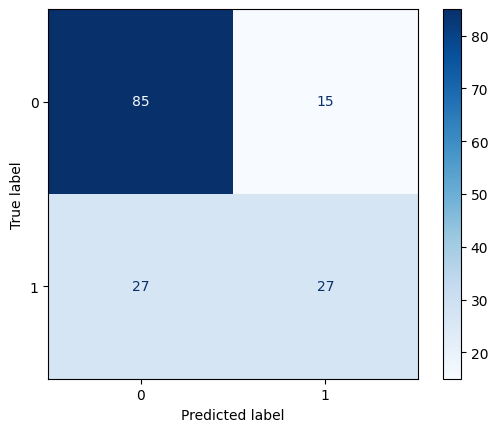

In [31]:
#Matriz de confusión
cm_gini = confusion_matrix(y_test, y_pred_gini)
ConfusionMatrixDisplay(cm_gini, display_labels=tree_gini.classes_).plot(cmap="Blues")

## Interpretación:

1. Verdaderos negativos: 85 casos bien clasificados sin diabetes
2. Verdaderos positivos: 27 casos bien clasificados con diabetes
3. Falsos positivos: 15 casos detectados como diabetes sin ser diabetes
4. Falsos negativos: 27 casos de no detectar diabetes cuando no hay

Este modelo de árbol de decisión obtuvo un accuracy de 73% mostrando un buen rendimiento en la clase de "no diabetes" pero con baja capacidad de detectar los casos positivos (recall del 50%). Médicamente es un problema porque el modelo tiene problemas para identificar pacientes con diabetes, observado en un número considerable de falsos negativos, lo cual es crítico en este tipo de problemas.

## Paso4. Optimización

In [32]:
pipeline = Pipeline([
    #Cómo se observó en el EDA, algunos campos tienen muchos ceros que ahora serán sustituidos por la mediana de cada columna para intentar mejorar el rendimiento del modelo.
    ("imputer", SimpleImputer(missing_values=0, strategy="median")),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

In [33]:
#Adaptamos el param_grid
param_grid = {
    "classifier__criterion": ["gini", "entropy"],
    "classifier__max_depth": [3, 5, 7],
    "classifier__max_features": ["sqrt", "log2", None],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4]
}

In [34]:
#Ejecutamos la búsqueda de hiperparámetros óptimos con GridSearchCV
grid = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)
grid.fit(X_train, y_train)
print(f"Mejores hiperparámetros: {grid.best_params_}")

Fitting 5 folds for each of 162 candidates, totalling 810 fits
Mejores hiperparámetros: {'classifier__criterion': 'entropy', 'classifier__max_depth': 7, 'classifier__max_features': 'log2', 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 10}


In [35]:
#EValuación del modelo optimizado
y_pred_opt = grid.predict(X_test)
print("Reporte de clasificación (Optimizado):")
print(classification_report(y_test, y_pred_opt))

Reporte de clasificación (Optimizado):
              precision    recall  f1-score   support

           0       0.72      0.83      0.77       100
           1       0.56      0.41      0.47        54

    accuracy                           0.68       154
   macro avg       0.64      0.62      0.62       154
weighted avg       0.67      0.68      0.67       154



In [36]:
#Incluimos una comparativa del classificacion report de ambos modelos para ver la mejora obtenida con la optimización de hiperparámetros.
print("Reporte de clasificación (Gini):")
print(classification_report(y_test, y_pred_gini))
print("Reporte de clasificación (Optimizado):")
print(classification_report(y_test, y_pred_opt))

Reporte de clasificación (Gini):
              precision    recall  f1-score   support

           0       0.76      0.85      0.80       100
           1       0.64      0.50      0.56        54

    accuracy                           0.73       154
   macro avg       0.70      0.68      0.68       154
weighted avg       0.72      0.73      0.72       154

Reporte de clasificación (Optimizado):
              precision    recall  f1-score   support

           0       0.72      0.83      0.77       100
           1       0.56      0.41      0.47        54

    accuracy                           0.68       154
   macro avg       0.64      0.62      0.62       154
weighted avg       0.67      0.68      0.67       154

